In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset structure

In [2]:
df = pd.read_csv(Path("../data/processed/data_weather.csv"), sep=";")
df_ap = pd.read_csv(Path("../data/processed/data_weather_ap.csv"), sep=";")
print("df shape:", df.shape, "& df_ap shape:", df_ap.shape)

df shape: (9531, 58) & df_ap shape: (6532, 88)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9531 entries, 0 to 9530
Data columns (total 58 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NUM_POSTE  9531 non-null   int64  
 1   NOM_USUEL  9531 non-null   str    
 2   LAT        9531 non-null   float64
 3   LON        9531 non-null   float64
 4   ALTI       9531 non-null   int64  
 5   AAAAMMJJ   9531 non-null   int64  
 6   RR         7392 non-null   float64
 7   QRR        7392 non-null   float64
 8   TN         6513 non-null   float64
 9   QTN        6513 non-null   float64
 10  HTN        6508 non-null   float64
 11  QHTN       6509 non-null   float64
 12  TX         6514 non-null   float64
 13  QTX        6514 non-null   float64
 14  HTX        6508 non-null   float64
 15  QHTX       6509 non-null   float64
 16  TM         6512 non-null   float64
 17  QTM        6516 non-null   float64
 18  TNTXM      6510 non-null   float64
 19  QTNTXM     6510 non-null   float64
 20  TAMPLI     6510 non

In [4]:
# Changing the date format to datetime and name to 'Date'
df["AAAAMMJJ"] = pd.to_datetime(df["AAAAMMJJ"].astype(str), format="%Y%m%d")
df.rename(columns={"AAAAMMJJ":"Date"}, inplace=True)

df_ap["AAAAMMJJ"] = pd.to_datetime(df_ap["AAAAMMJJ"].astype(str), format="%Y%m%d")
df_ap.rename(columns={"AAAAMMJJ": "Date"}, inplace=True)

In [5]:
df_ap.shape

(6532, 88)

In [6]:
df_ap.loc[df_ap["UM"].notna(), "UM"].iloc[0]

np.float64(77.0)

Il existe 11 stations météo dans le fichier pour le département 75. Le nombre d'occurrences de ces stations est différent ce qui laisse supposer qu'elles ne mesurent pas toutes les mêmes variables météo.

In [7]:
# Number of unique stations, their names & their number of occurrences in the dataset
print("Number of unique stations:", df['NUM_POSTE'].nunique())
df[['NUM_POSTE', 'NOM_USUEL']].value_counts()

Number of unique stations: 11


NUM_POSTE  NOM_USUEL              
75106001   LUXEMBOURG                 1095
75110001   LARIBOISIERE               1095
75114001   PARIS-MONTSOURIS           1095
75114007   PARIS-MONTSOURIS-DOUBLE    1095
75116008   LONGCHAMP                  1095
75107005   TOUR EIFFEL                1044
75112004   ST-ANTOINE                  761
75119001   BUTTES CHAUMONT             761
75113002   SALPETRIERE                 730
75116002   BAGATELLE                   425
75112001   ILE DE BERCY                335
Name: count, dtype: int64

De nombreuses variables météo possèdent des valeurs manquantes dans le dataset ce qui confirme le fait que toutes les stations ne mesurent pas toutes les variables. De nombreuses variables sont également similaires (ex : TN, TX, TM)

In [8]:
# Checking for missing values
print(df.isna().sum().to_string())

NUM_POSTE       0
NOM_USUEL       0
LAT             0
LON             0
ALTI            0
Date            0
RR           2139
QRR          2139
TN           3018
QTN          3018
HTN          3023
QHTN         3022
TX           3017
QTX          3017
HTX          3023
QHTX         3022
TM           3019
QTM          3015
TNTXM        3021
QTNTXM       3021
TAMPLI       3021
QTAMPLI      3021
TNSOL        7341
QTNSOL       7341
TN50         8436
QTN50        8436
DG           3068
QDG          3067
FFM          6310
QFFM         6310
FF2M         9531
QFF2M        9531
FXY          6321
QFXY         6321
DXY          6322
QDXY         6321
HXY          6322
QHXY         6322
FXI          6311
QFXI         6311
DXI          6315
QDXI         6315
HXI          6313
QHXI         6313
FXI2         9531
QFXI2        9531
DXI2         9531
QDXI2        9531
HXI2         9531
QHXI2        9531
FXI3S        6311
QFXI3S       6311
DXI3S        6316
QDXI3S       6316
HXI3S        6313
QHXI3S    

In [9]:
# Checking for missing values
print(df_ap.isna().sum().to_string())

NUM_POSTE          0
NOM_USUEL          0
LAT                0
LON                0
ALTI               0
Date               0
DHUMEC          6532
QDHUMEC         6532
PMERM           5437
QPMERM          5437
PMERMIN         5437
QPMERMIN        5437
INST            4345
QINST           4345
GLOT            4343
QGLOT           4343
DIFT            6532
QDIFT           6532
DIRT            6532
QDIRT           6532
INFRART         6532
QINFRART        6532
UV              6532
QUV             6532
UV_INDICEX      6532
QUV_INDICEX     6532
SIGMA           4345
QSIGMA          4345
UN              4342
QUN             4342
HUN             4343
QHUN            4343
UX              4342
QUX             4342
HUX             4342
QHUX            4342
UM              4342
QUM             4342
DHUMI40         4355
QDHUMI40        4355
DHUMI80         4355
QDHUMI80        4355
TSVM            4342
QTSVM           4342
ETPMON          4347
QETPMON         4347
ETPGRILLE         13
QETPGRILLE   

Il peut être intéressant de regarder quelles stations mesurent quels paramètres météo. Pour le fichier data_weather_ap.csv, seules deux stations mesurent les variables météo qui pourraient nous intéresser, contrairement à data_weather.csv dont toutes les stations mesurent les variables qui nous intéressent pour notre projet.

In [10]:
df.groupby("NUM_POSTE")[["RR", "TNTXM", "FFM"]].count()

,RR,TNTXM,FFM
NUM_POSTE,,,
75106001,1095,1095,0
75107005,0,1035,1035
75110001,1095,1095,0
75112001,335,0,0
75112004,761,0,0
75113002,730,0,0
75114001,1095,1095,1095
75114007,0,1095,0
75116002,425,0,0


In [11]:
df_ap.groupby("NUM_POSTE")[["GLOT", "UM", "PMERM"]].count()

,GLOT,UM,PMERM
NUM_POSTE,,,
75106001,0,0,0
75107005,0,0,0
75110001,0,0,0
75112001,0,0,0
75114001,1095,1095,1095
75114007,0,0,0
75116008,1094,1095,0
75119001,0,0,0


In [12]:
df_full = pd.merge(df, df_ap, on=["Date", "NUM_POSTE"], how="outer")
df_full.head()

,NUM_POSTE,NOM_USUEL_x,LAT_x,LON_x,ALTI_x,Date,RR,QRR,TN,QTN,...,ECLAIR,QECLAIR,NB300,QNB300,BA300,QBA300,TMERMIN,QTMERMIN,TMERMAX,QTMERMAX
0,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-01,0.0,1.0,0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,75107005,TOUR EIFFEL,48.858333,2.294500,330,2021-01-01,NaN,NaN,-0.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,75110001,LARIBOISIERE,48.882833,2.352000,55,2021-01-01,0.0,1.0,1.4,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,75112001,ILE DE BERCY,48.831667,2.411667,50,2021-01-01,0.2,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,75112004,ST-ANTOINE,48.848167,2.380833,36,2021-01-01,0.3,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploratory Data Analysis

Les variables météo qui peuvent être utiles pour notre projet sur la qualité de l'air sont les suivantes :
- RR : quantité de précipitation tombée en 24 heures (de 06h FU le jour J à 06h FU le jour J+1) en mm.
- TN : température minimale sous abri (en °C).
- TX : température maximale sous abri (en °C).
- TM : moyenne quotidienne des températures horaires sous abri (en °C).
- TNTXM : moyenne quotidienne (TN+TX)/2 (en °C).
- FFM : moyenne quotidienne de la force du vent moyenné sur 10 minutes, à 10 m (en m/s).
- FXY : maximum quotidien de la force maximale horaire du vent moyenné sur 10 minutes, à 10 m (en m/s).
- FXI : maximum quotidien de la force maximale horaire du vent instantané, à 10 m (en m/s).<br>

Les variables de température, et les variables de vent étant très corrélées entre elles, on n'en retiendra qu'une ou deux pour chaque catégorie. Pour les précipitations, il n'y en a qu'une : RR. Pour la température, TM et TNTXM sont les plus intéressantes, et corrélées à 0.99. On retient TNTXM qui possède tout juste plus d'observations que TM. Pour le vent, on retient pour l'instant FFM (vent moyen sur la journée) et FXY (vent maximum de la journée moyenné sur 10min). Par la suite, il sera intéressant de trancher entre l'une de ces deux variables pour savoir celle qui a le plus d'effet sur les concentrations en PM10 et O3.

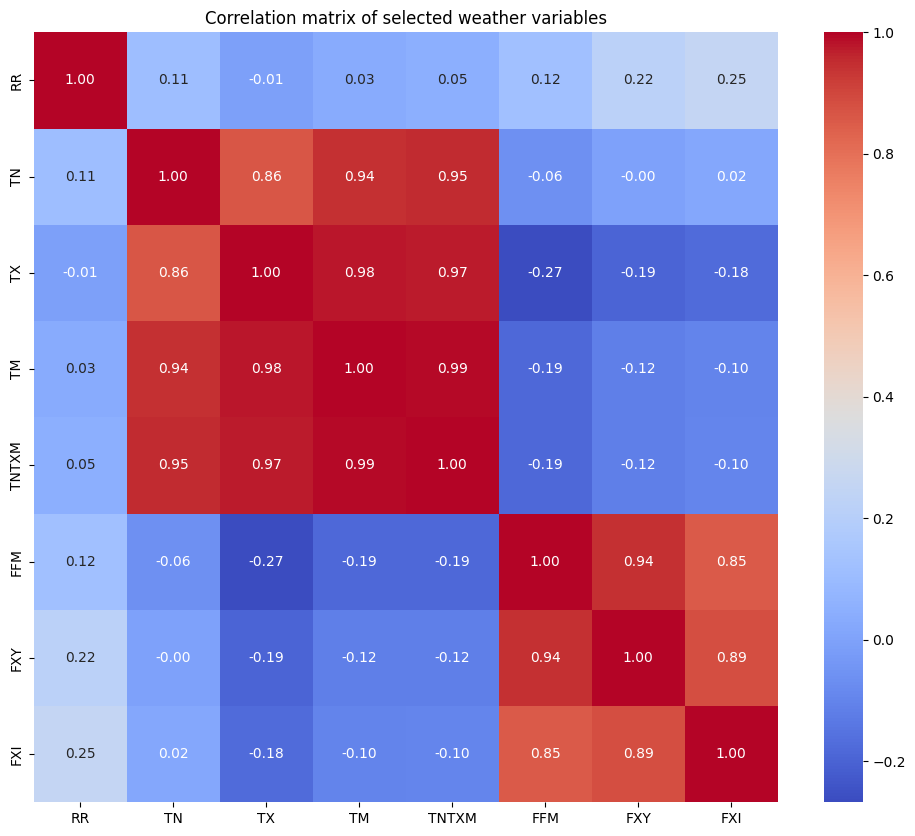

In [38]:
# Weather variables to analyze (which could be helpful for understanding air quality)
weather_vars = ["RR", "TN", "TX", "TM", "TNTXM", "FFM", "FXY", "FXI"]

df_corr = df[weather_vars]

# Correlation matrix
corr_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix of selected weather variables')
plt.show()

Les variables suivantes contenues dans l'autre dataset peuvent également nous intéresser :
- PMERM : pression atmosphérique moyenne quotidienne au niveau de la mer, utile pour analyser les conditions de stabilité de l’air.
- PMERMIN : pression minimale quotidienne, pouvant indiquer des variations météorologiques importantes (dépressions).
- INST : durée d’insolation quotidienne (ensoleillement), directement liée à la formation de l’ozone.
- GLOT : rayonnement global quotidien, indicateur clé de l’énergie solaire reçue et donc de la photochimie atmosphérique.
- SIGMA : fraction d’insolation par rapport à la durée du jour, permettant d’évaluer la nébulosité relative.
- UN : humidité relative minimale quotidienne, utile pour caractériser les conditions les plus sèches de la journée.
- UX : humidité relative maximale quotidienne, représentant les conditions les plus humides.
- UM : humidité relative moyenne quotidienne, indicateur global de l’humidité de l’air, souvent corrélé à la formation de particules.
- DHUMI40 : durée pendant laquelle l’humidité relative est inférieure ou égale à 40 %, traduisant des conditions très sèches.
- DHUMI80 : durée pendant laquelle l’humidité relative est supérieure ou égale à 80 %, associée à des conditions humides ou brumeuses.
- TSVM : tension de vapeur moyenne, liée à la quantité de vapeur d’eau dans l’air et donc à l’humidité absolue.
- ETPMON : évapotranspiration potentielle (méthode de Monteith), représentant les échanges d’eau entre le sol et l’atmosphère.
- ETPGRILLE : évapotranspiration calculée au point de grille le plus proche, permettant une estimation spatialisée de ces flux.
- NEIGETOTX : épaisseur maximale de neige quotidienne, utile pour caractériser les épisodes neigeux intenses.
- NEIGETOT06 : épaisseur totale de neige au sol mesurée à 6h, indicateur de l’accumulation de neige persistante.

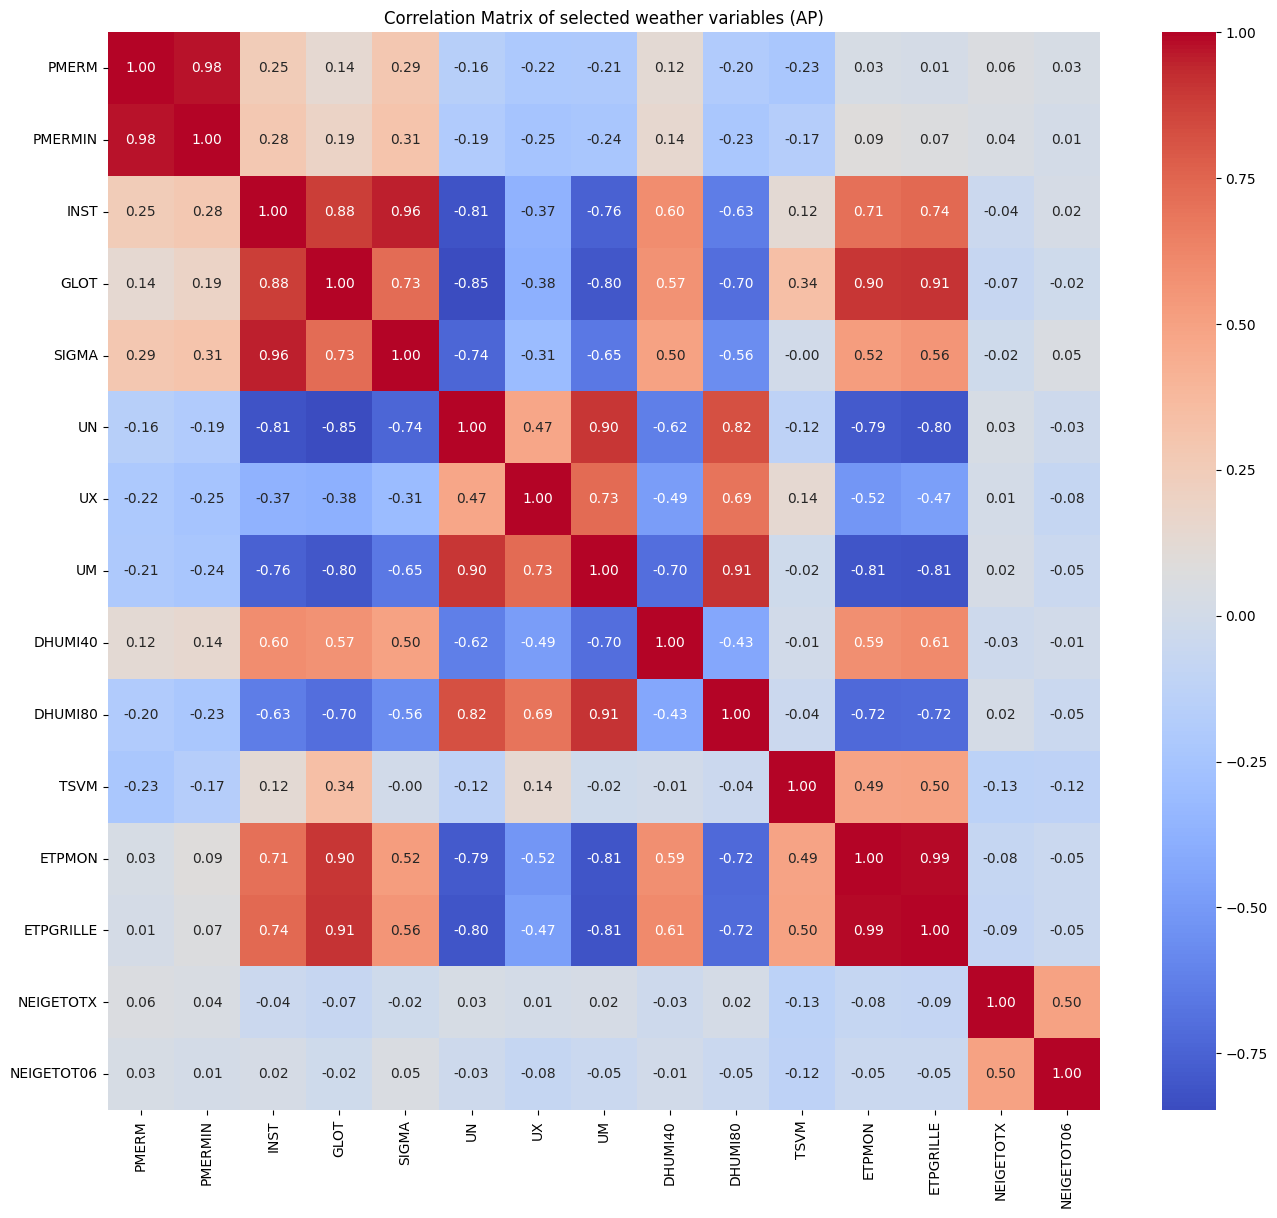

In [14]:
weather_vars_ap = ["PMERM", "PMERMIN", "INST", "GLOT", "SIGMA", "UN", "UX", "UM", "DHUMI40", "DHUMI80",
    "TSVM", "ETPMON", "ETPGRILLE", "NEIGETOTX", "NEIGETOT06"]

df_corr_ap = df_ap[weather_vars_ap]

# Correlation matrix
corr_matrix_ap = df_corr_ap.corr()
# Heatmap
plt.figure(figsize=(16,14))
sns.heatmap(corr_matrix_ap, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of selected weather variables (AP)')
plt.show()

Les corrélations entre les paramètres retenus sont affichées dans la matrice suivante. On remarque des corrélations logiques telles que température-ensoleillement, mais la valeur de corrélation n'étant pas non plus proche de 1, on peut envisager de garder ces deux variables dans le modèle. Pareil pour les corrélations négatives telles que température-humidité ou pluie-humidité.<br>
Il faudra par contre faire un choix entre GLOT et UM très inversement corrélées.

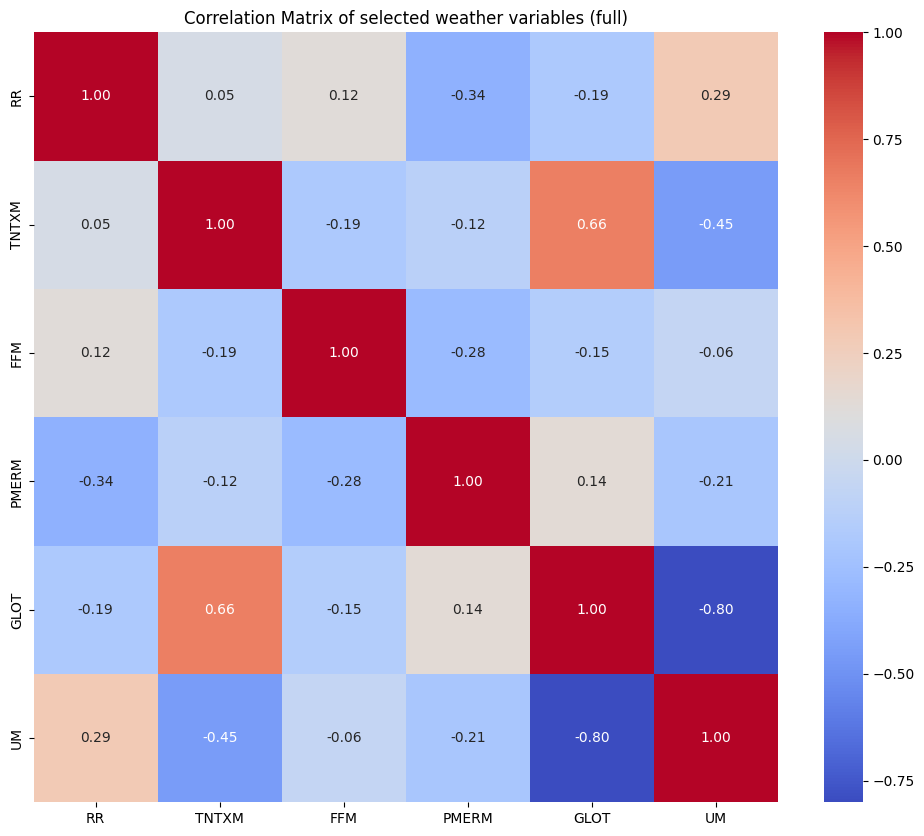

In [15]:
all_weather_vars = ["RR", "TNTXM", "FFM", "PMERM", "GLOT", "UM"]

# Correlation matrix
corr_matrix_full = df_full[all_weather_vars].corr()
# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix_full, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of selected weather variables (full)')
plt.show()

Parmi les 11 stations météo, seules les stations Luxembourg, Tour Eiffel, Lariboiserie, Montsouris, Montsouris-Double et Longchamp captent les valeurs de température. Les valeurs de corrélation sont toutes supérieures à 0.96 ce qui montre que la température est très similaire entre les différentes stations.

In [16]:
# Correlation between each station for temperature
df_pivot = df.pivot_table(index='Date', columns='NUM_POSTE', values='TNTXM')
corr_stations_tm = df_pivot.corr()
print("Correlation between each station for temperature:\n", corr_stations_tm)

Correlation between each station for temperature:
 NUM_POSTE  75106001  75107005  75110001  75114001  75114007  75116008
NUM_POSTE                                                            
75106001   1.000000  0.982617  0.995182  0.997802  0.997540  0.987879
75107005   0.982617  1.000000  0.991528  0.985735  0.986393  0.965650
75110001   0.995182  0.991528  1.000000  0.996881  0.997088  0.982107
75114001   0.997802  0.985735  0.996881  1.000000  0.999555  0.986387
75114007   0.997540  0.986393  0.997088  0.999555  1.000000  0.986787
75116008   0.987879  0.965650  0.982107  0.986387  0.986787  1.000000


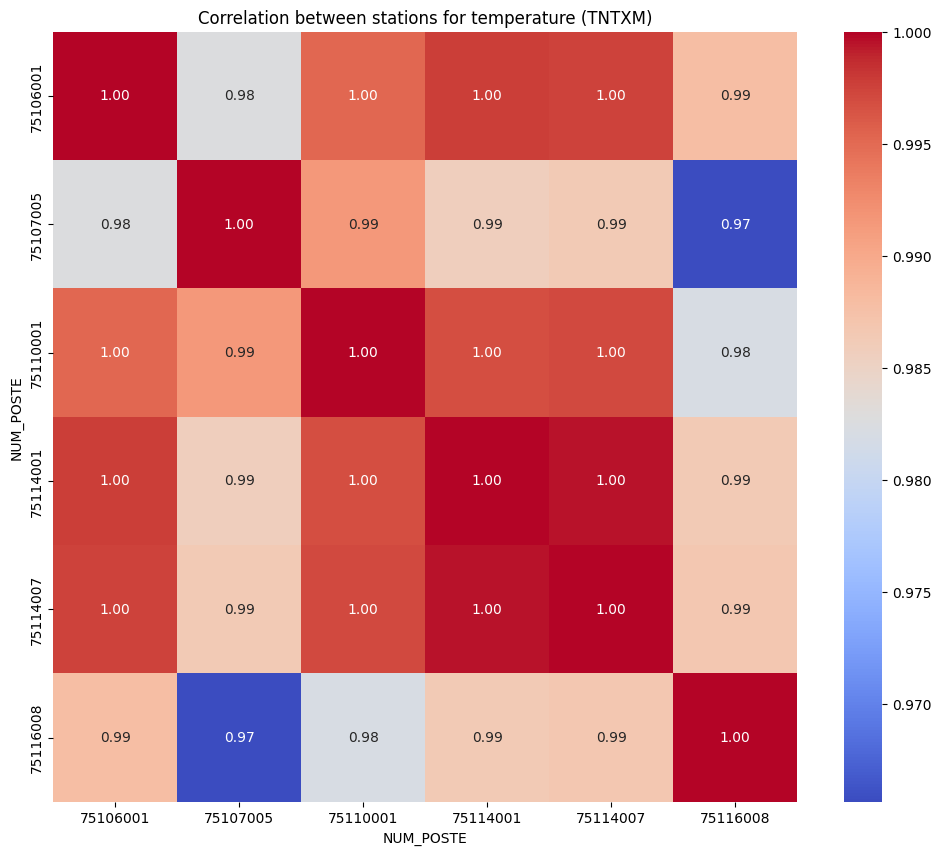

In [39]:
# Heatmap of the correlation between stations for temperature
plt.figure(figsize=(12,10))
sns.heatmap(corr_stations_tm, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation between stations for temperature (TNTXM)')
plt.show()

Parmi les 11 stations météo, seules les stations Luxembourg, Lariboiserie, Ile de Bercy, St-Antoine, Salpetriere, Montsouris, Bagatelle, Longchamp et Buttes Chaumont captent les valeurs de précipitations. Les valeurs de corrélation sont toutes supérieures à 0.86, et en moyenne supérieures à 0.90, ce qui montre que les précipitations sont également plutôt similaires entre les différentes stations.

In [17]:
# Correlation between each station for precipitations
df_pivot = df.pivot_table(index='Date', columns='NUM_POSTE', values='RR')
corr_stations_rr = df_pivot.corr()
print("Correlation between each station for precipitations:\n", corr_stations_rr)

Correlation between each station for precipitations:
 NUM_POSTE  75106001  75110001  75112001  75112004  75113002  75114001  \
NUM_POSTE                                                               
75106001   1.000000  0.943347  0.936405  0.966428  0.970063  0.965617   
75110001   0.943347  1.000000  0.915141  0.945337  0.939906  0.899371   
75112001   0.936405  0.915141  1.000000  0.954596  0.964132  0.938590   
75112004   0.966428  0.945337  0.954596  1.000000  0.986466  0.957044   
75113002   0.970063  0.939906  0.964132  0.986466  1.000000  0.965668   
75114001   0.965617  0.899371  0.938590  0.957044  0.965668  1.000000   
75116002   0.932236  0.870730  0.873078  0.893258  0.922541  0.940358   
75116008   0.919235  0.888379  0.862707  0.890683  0.901017  0.900958   
75119001   0.944760  0.970823  0.936698  0.963918  0.958518  0.922968   

NUM_POSTE  75116002  75116008  75119001  
NUM_POSTE                                
75106001   0.932236  0.919235  0.944760  
75110001   0.870

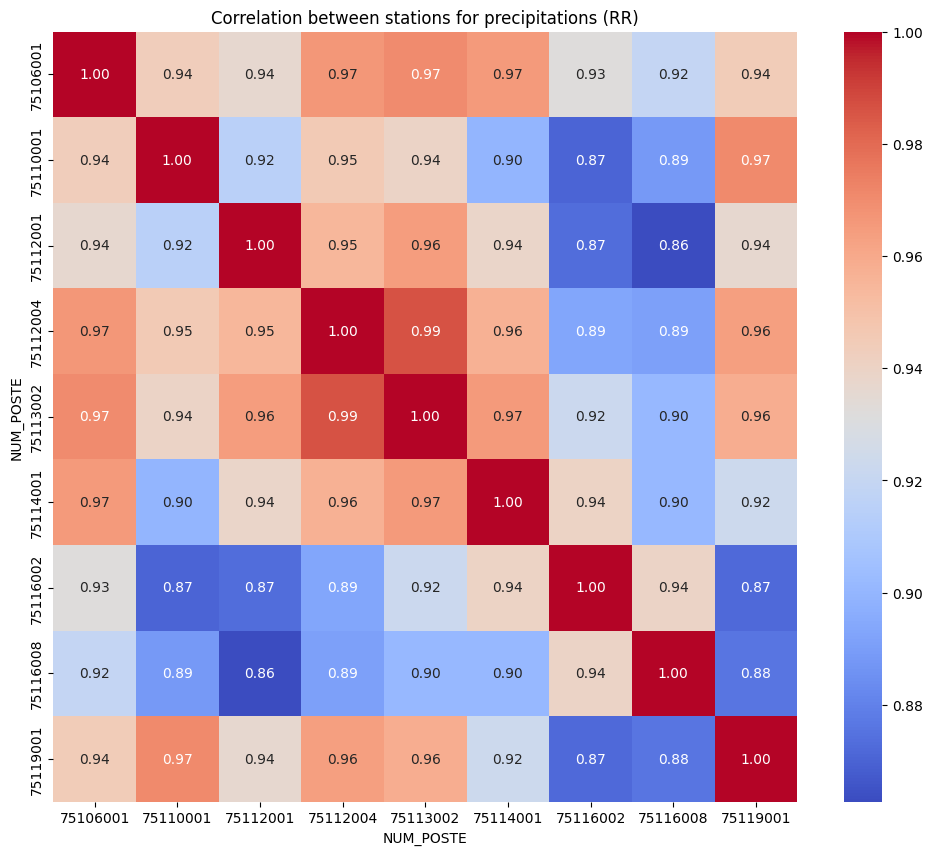

In [40]:
# Heatmap of the correlation between stations for precipitations
plt.figure(figsize=(12,10))
sns.heatmap(corr_stations_rr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation between stations for precipitations (RR)')
plt.show()

Parmi les 11 stations météo, seules trois stations captent les données de vitesse du vent : Tour Eiffel, Montsouris et Longchamp. Les valeurs de corrélation sont plus mauvaises ici, mais tout de même supérieures à 0.80. Le vent est donc la variable qui possède le plus de variabilités géographiques. Comme première hypothèse, on peut estimer un vent moyen pour tout Paris et revenir sur ce point plus tard pour améliorer la prédiction.

In [18]:
# Correlation between each station for wind
df_pivot = df.pivot_table(index='Date', columns='NUM_POSTE', values='FFM')
corr_stations_ffm = df_pivot.corr()
print("Correlation between each station for wind (FFM):\n", corr_stations_ffm)

Correlation between each station for wind (FFM):
 NUM_POSTE  75107005  75114001  75116008
NUM_POSTE                              
75107005   1.000000  0.836610  0.808789
75114001   0.836610  1.000000  0.960915
75116008   0.808789  0.960915  1.000000


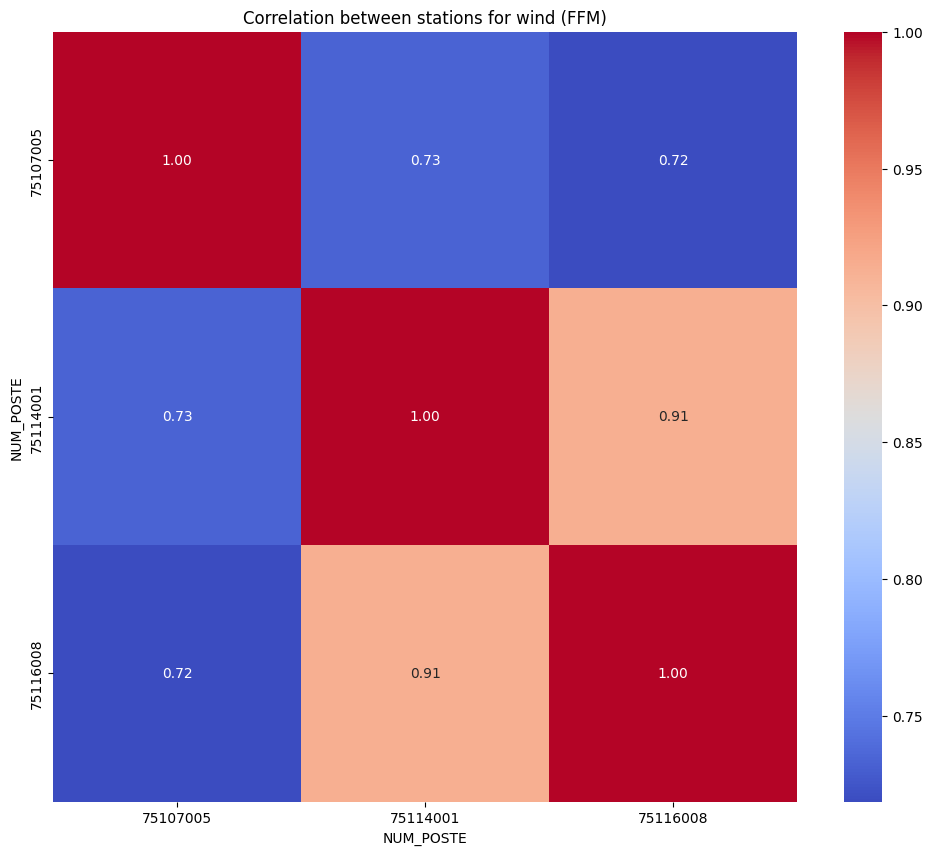

In [41]:
# Heatmap of the correlation between stations for wind
plt.figure(figsize=(12,10))
sns.heatmap(corr_stations_ffm, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation between stations for wind (FFM)')
plt.show()

Pour la variable vent max moyenné sur 10min, les variabilités géographiques sont encore plus marquées.

In [19]:
# Correlation between each station for wind
df_pivot = df.pivot_table(index='Date', columns='NUM_POSTE', values='FXY')
corr_stations_ffm = df_pivot.corr()
print("Correlation between each station for wind (FXY):\n", corr_stations_ffm)

Correlation between each station for wind (FXY):
 NUM_POSTE  75107005  75114001  75116008
NUM_POSTE                              
75107005   1.000000  0.733943  0.718591
75114001   0.733943  1.000000  0.914181
75116008   0.718591  0.914181  1.000000


Les stations mesurant les "autres paramètres" sont au nombre de deux et mesurent quasiment les mêmes valeurs.

In [20]:
# Correlation between each station for atmospheric pressure
df_pivot = df_ap.pivot_table(index='Date', columns='NUM_POSTE', values='PMERM')
corr_stations_pmerm = df_pivot.corr()
print("Correlation between each station for PMERM:\n", corr_stations_pmerm)

Correlation between each station for PMERM:
 NUM_POSTE  75114001
NUM_POSTE          
75114001        1.0


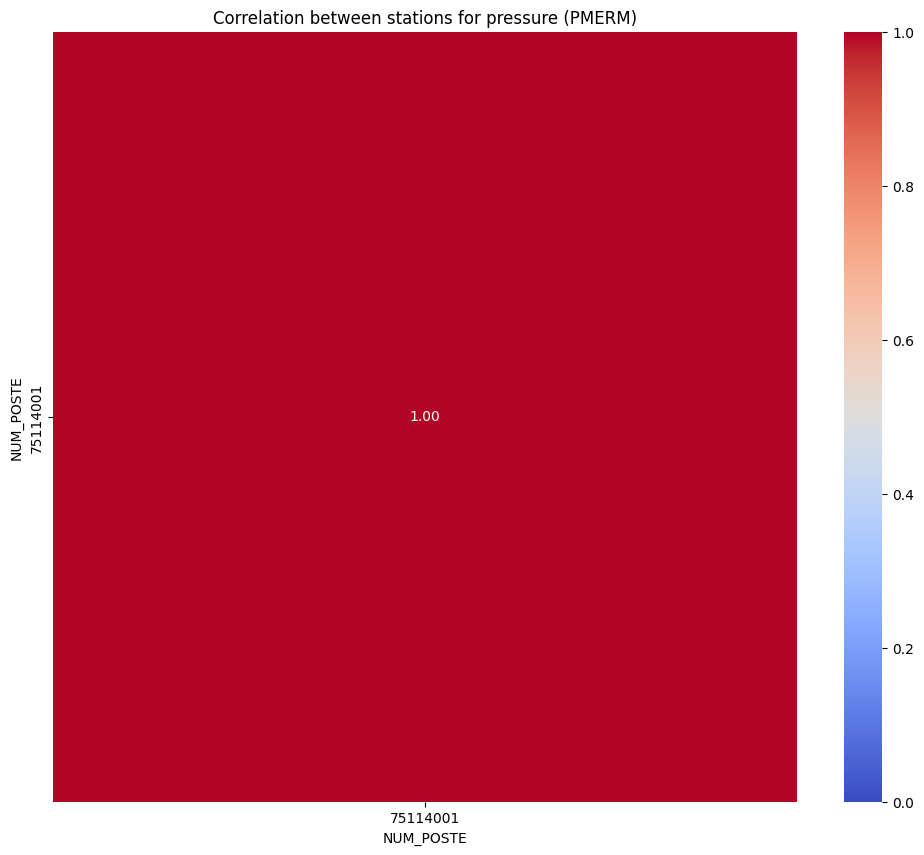

In [45]:
# Heatmap of the correlation between stations for pressure
plt.figure(figsize=(12,10))
sns.heatmap(corr_stations_pmerm, annot=True, fmt=".2f", cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation between stations for pressure (PMERM)')
plt.show()

In [21]:
# Correlation between each station for humidity
df_pivot = df_ap.pivot_table(index='Date', columns='NUM_POSTE', values='UM')
corr_stations_um = df_pivot.corr()
print("Correlation between each station for UM:\n", corr_stations_um)

Correlation between each station for UM:
 NUM_POSTE  75114001  75116008
NUM_POSTE                    
75114001   1.000000  0.954951
75116008   0.954951  1.000000


In [22]:
# Correlation between each station for solar radiation
df_pivot = df_ap.pivot_table(index='Date', columns='NUM_POSTE', values='GLOT')
corr_stations_glot = df_pivot.corr()
print("Correlation between each station for GLOT:\n", corr_stations_glot)

Correlation between each station for GLOT:
 NUM_POSTE  75114001  75116008
NUM_POSTE                    
75114001   1.000000  0.994529
75116008   0.994529  1.000000


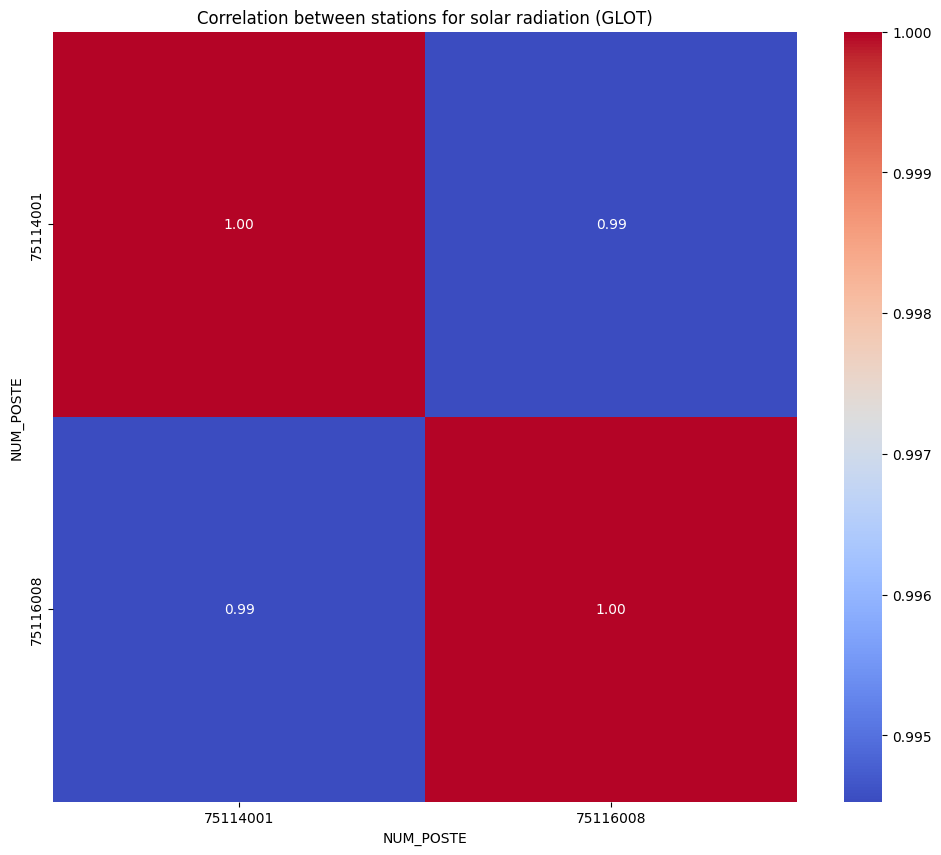

In [42]:
# Heatmap of the correlation between stations for solar radiation
plt.figure(figsize=(12,10))
sns.heatmap(corr_stations_glot, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation between stations for solar radiation (GLOT)')
plt.show()

Calcul des moyennes sur la journée, par station

In [23]:
df_weather_daily = df.groupby(["Date", "NUM_POSTE"])[["RR", "TNTXM", "FFM", "FXY"]].mean().reset_index()
df_weather_daily.head()

,Date,NUM_POSTE,RR,TNTXM,FFM,FXY
0,2021-01-01,75106001,0.0,2.5,NaN,NaN
1,2021-01-01,75107005,NaN,0.5,3.2,4.9
2,2021-01-01,75110001,0.0,2.8,NaN,NaN
3,2021-01-01,75112001,0.2,NaN,NaN,NaN
4,2021-01-01,75112004,0.3,NaN,NaN,NaN


In [24]:
df_weather_ap_daily = df_ap.groupby(["Date", "NUM_POSTE"])[["PMERM", "UM", "GLOT"]].mean().reset_index()
df_weather_ap_daily.head()

,Date,NUM_POSTE,PMERM,UM,GLOT
0,2021-01-01,75106001,NaN,NaN,NaN
1,2021-01-01,75107005,NaN,NaN,NaN
2,2021-01-01,75110001,NaN,NaN,NaN
3,2021-01-01,75114001,1011.3,77.0,358.0
4,2021-01-01,75114007,NaN,NaN,NaN


In [25]:
palette = sns.color_palette("Set2")

La température est majoritairement située entre 8 et 23°C.<br>
La vitesse moyenne du vent se trouve généralement entre 2 et 5m/s (respectivement 7 et 18km/h).<br>
Les précipitations sont souvent à 0.

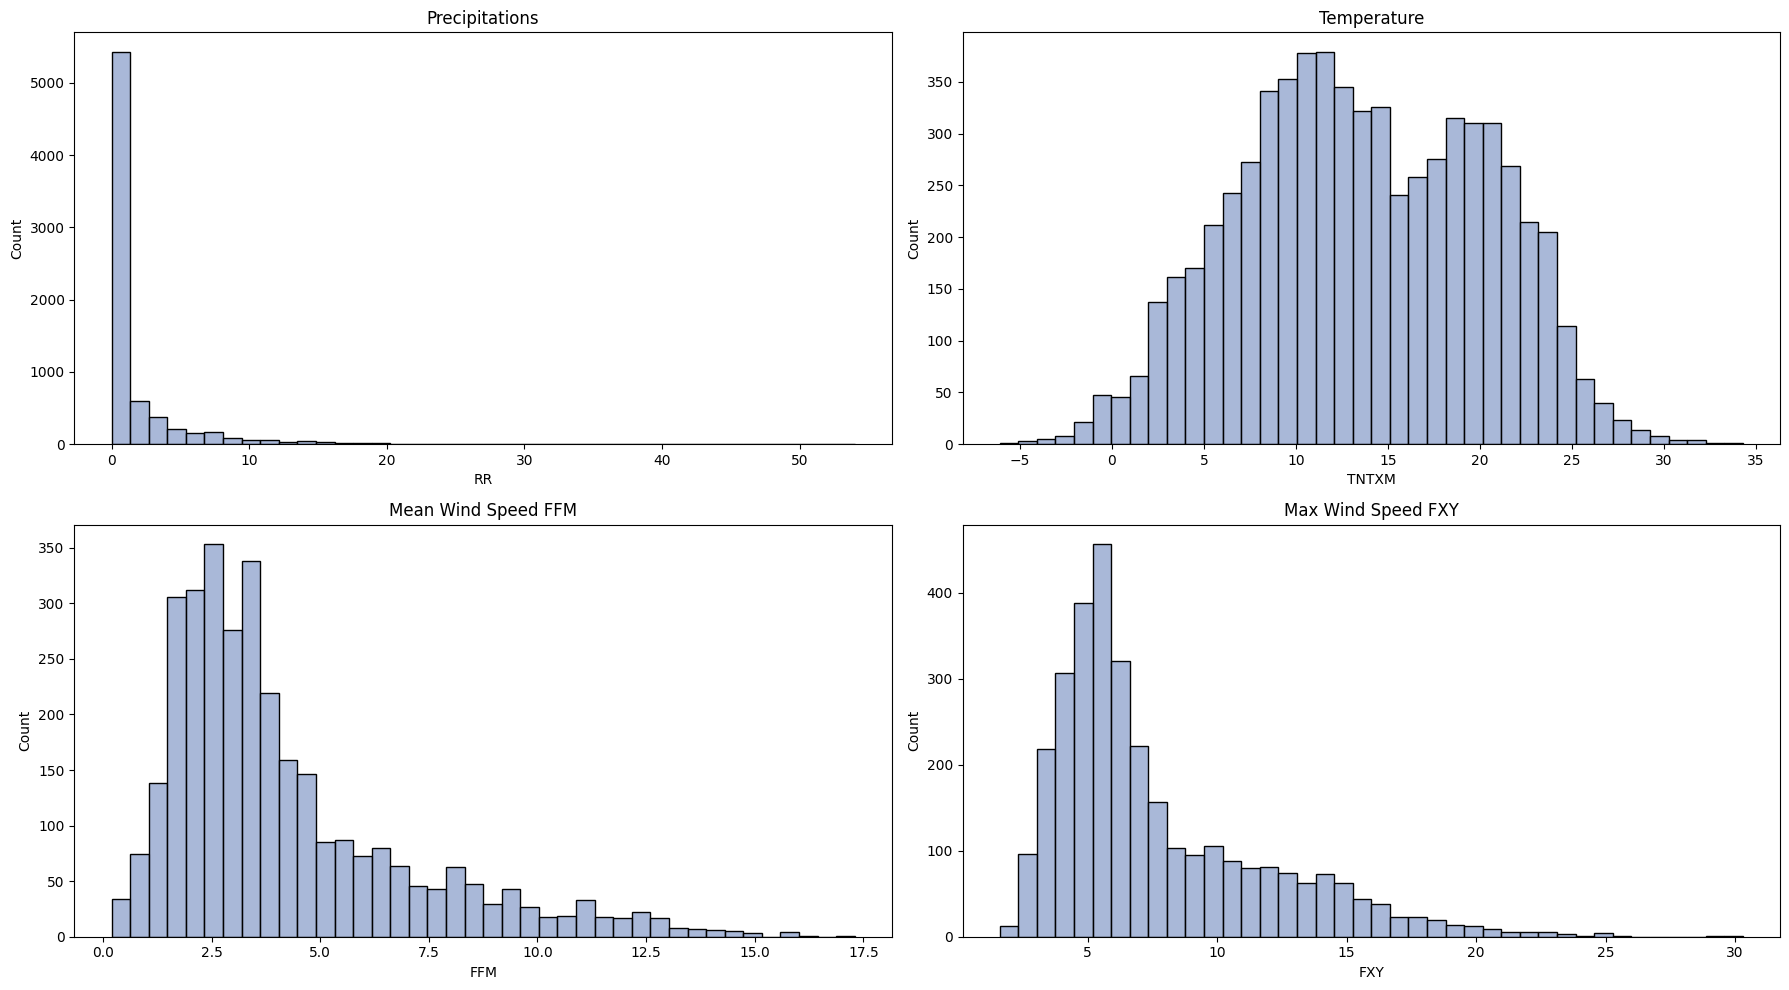

In [26]:
# Histograms for temperature, wind and precipitations
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.histplot(df_weather_daily['RR'], bins=40, ax=axes[0, 0], color=palette[2])
axes[0, 0].set_title('Precipitations')

sns.histplot(df_weather_daily['TNTXM'], bins=40, ax=axes[0, 1], color=palette[2])
axes[0, 1].set_title('Temperature')

sns.histplot(df_weather_daily['FFM'], bins=40, ax=axes[1, 0], color=palette[2])
axes[1, 0].set_title('Mean Wind Speed FFM')

sns.histplot(df_weather_daily['FXY'], bins=40, ax=axes[1, 1], color=palette[2])
axes[1, 1].set_title('Max Wind Speed FXY')

plt.tight_layout()
plt.show()

In [27]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.dayofyear
df.head()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,Date,RR,QRR,TN,QTN,...,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,Year,Month,Day
0,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-01,0.0,1.0,0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,1
1,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-02,0.2,1.0,-1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,2
2,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-03,0.0,1.0,2.8,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,3
3,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-04,0.0,1.0,2.5,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,4
4,75106001,LUXEMBOURG,48.844667,2.333833,46,2021-01-05,0.2,1.0,2.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,1,5


In [28]:
import matplotlib.dates as mdates

Les températures sont plus élevées en été.

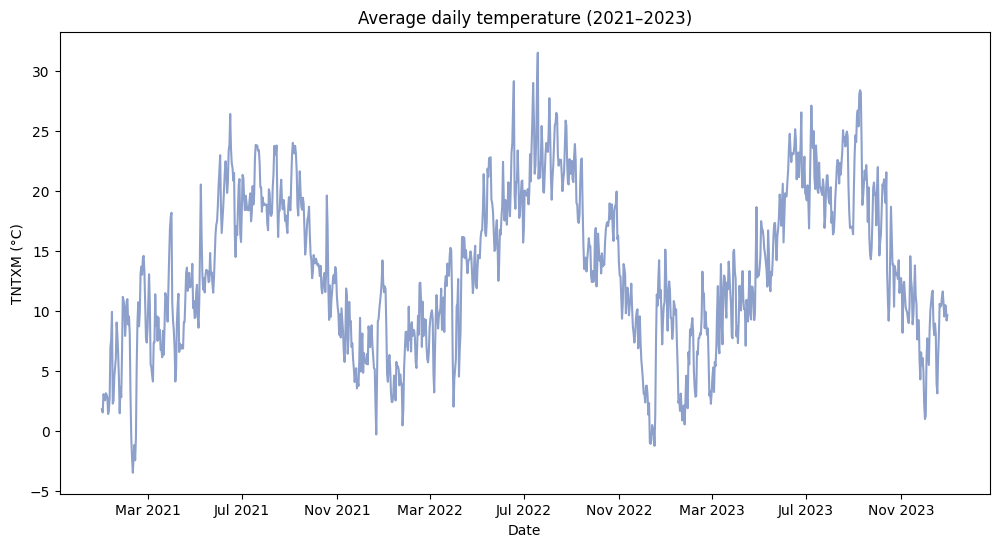

In [29]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data = df[df['Year'].isin([2021, 2022, 2023])],
    x='Date',
    y='TNTXM',
    errorbar=None,
    color=palette[2]
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Average daily temperature (2021–2023)')
plt.xlabel('Date')
plt.ylabel('TNTXM (°C)')
plt.show()

La représentation temporelle de la force du vent sur trois années semble montrer un vent plus fort de novembre à avril, et plus faible de mai à octobre.

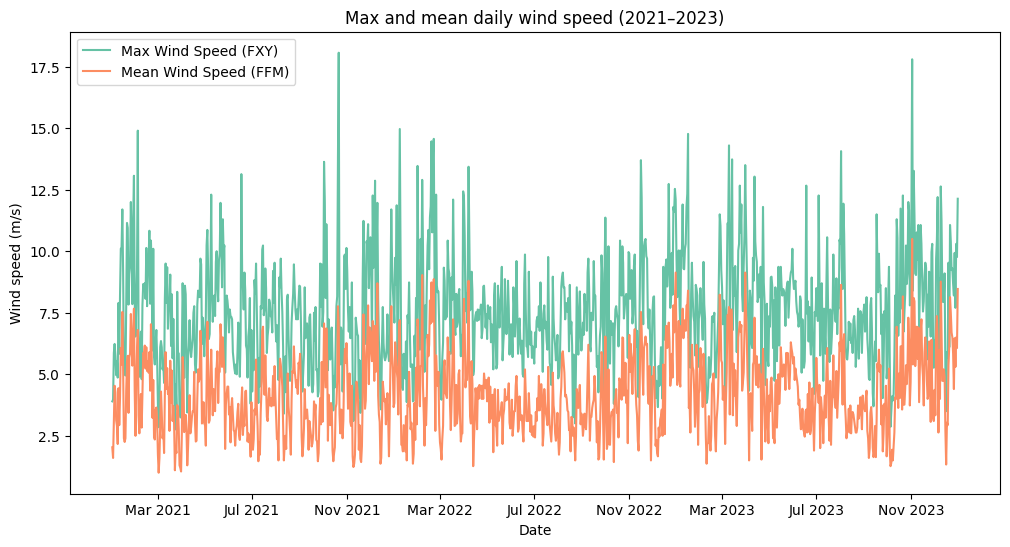

In [30]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,6))
sns.lineplot(
    data = df[df['Year'].isin([2021, 2022, 2023])],
    x='Date',
    y='FXY',
    errorbar=None,
    color=palette[0],
    label='Max Wind Speed (FXY)'
)

sns.lineplot(
    data = df[df['Year'].isin([2021, 2022, 2023])],
    x='Date',
    y='FFM',
    errorbar=None,
    color=palette[1],
    label='Mean Wind Speed (FFM)'
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title('Max and mean daily wind speed (2021–2023)')
plt.xlabel('Date')
plt.ylabel('Wind speed (m/s)')
plt.legend()
plt.show()

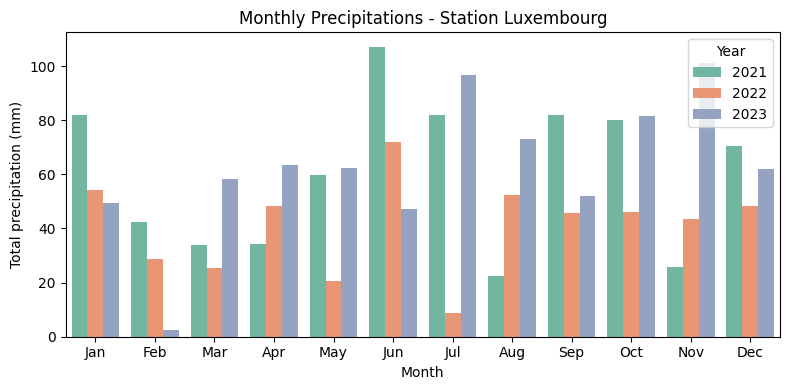

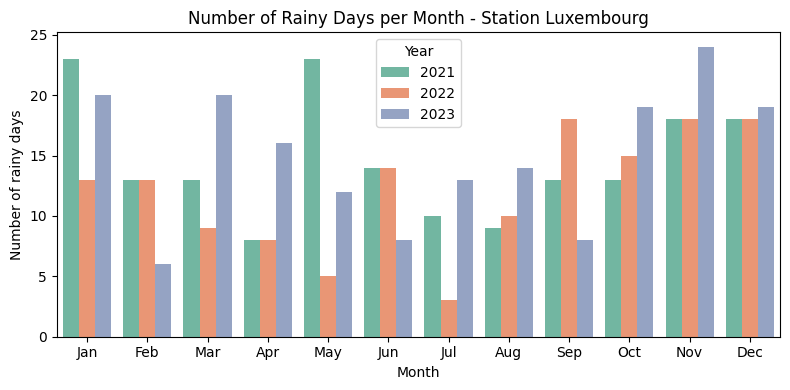

In [31]:
station_id = 75106001
# Filtering data for the chosen station
df_station = df[df['NUM_POSTE'] == station_id].copy()

# Month mapping
month_labels = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Precipitation per month and year
df_monthly_rr = (
    df_station
    .groupby(['Year', 'Month'])['RR']
    .sum()
    .reset_index()
)

df_monthly_rr['Month_label'] = df_monthly_rr['Month'].map(month_labels)
df_monthly_rr['Month_label'] = pd.Categorical(
    df_monthly_rr['Month_label'],
    categories=month_order,
    ordered=True
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_monthly_rr,
    x='Month_label',
    y='RR',
    hue='Year',
    palette='Set2'
)

plt.title(f'Monthly Precipitations - Station Luxembourg')
plt.xlabel('Month')
plt.ylabel('Total precipitation (mm)')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Number of rainy days (RR > 0)
df_station['RainyDay'] = df_station['RR'] > 0

df_monthly_rainy_days = (
    df_station
    .groupby(['Year', 'Month'])['RainyDay']
    .sum()
    .reset_index()
)

df_monthly_rainy_days['Month_label'] = df_monthly_rainy_days['Month'].map(month_labels)
df_monthly_rainy_days['Month_label'] = pd.Categorical(
    df_monthly_rainy_days['Month_label'],
    categories=month_order,
    ordered=True
)

plt.figure(figsize=(8,4))
sns.barplot(
    data=df_monthly_rainy_days,
    x='Month_label',
    y='RainyDay',
    hue='Year',
    palette='Set2'
)

plt.title(f'Number of Rainy Days per Month - Station Luxembourg')
plt.xlabel('Month')
plt.ylabel('Number of rainy days')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

Le même travail est effectué pour les autres paramèters

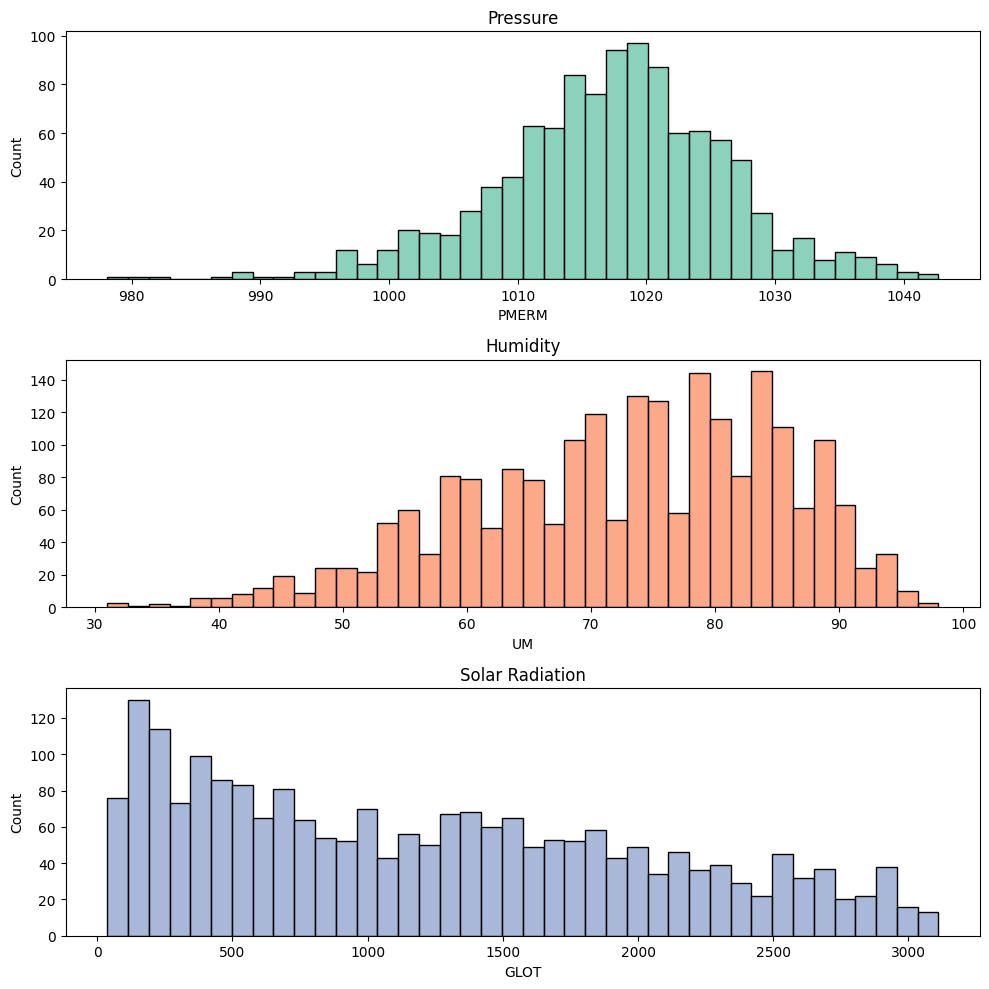

In [32]:
# Histograms for pressure, humidity and solar radiation
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

sns.histplot(df_weather_ap_daily["PMERM"], bins=40, ax=axes[0], color=palette[0])
axes[0].set_title('Pressure')

sns.histplot(df_weather_ap_daily["UM"], bins=40, ax=axes[1], color=palette[1])
axes[1].set_title('Humidity')

sns.histplot(df_weather_ap_daily["GLOT"], bins=40, ax=axes[2], color=palette[2])
axes[2].set_title('Solar Radiation')

plt.tight_layout()
plt.show()

On observe une forte saisonnalité pour GLOT rayonnement solaire : celui-ci est bien plus important en été qu'en hiver.<br>
La saisonnalité est inversée pour l'humidité : elle est plus forte en hiver.<br>
Pour la pression atmosphérique, la saisonnalité est quasi inexistante, bien qu'on remarque quelques pics élevés en début d'année.

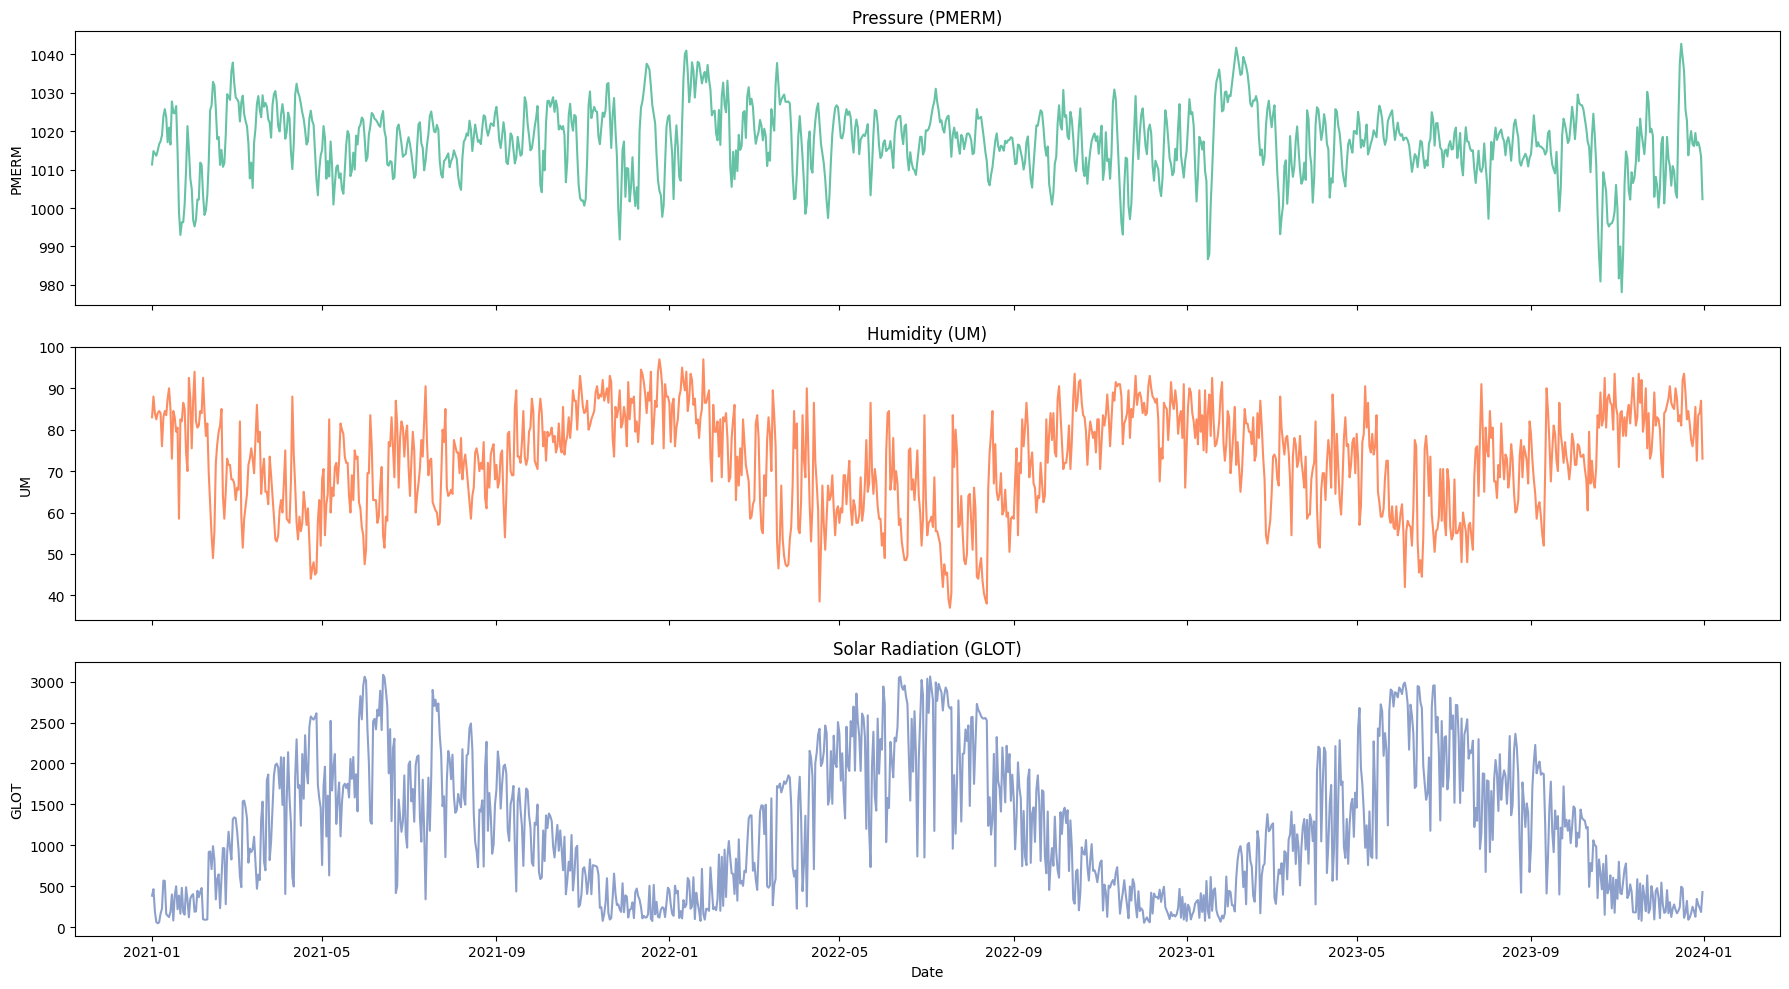

In [33]:
# Vérifier le format date
df_weather_ap_daily["Date"] = pd.to_datetime(df_weather_ap_daily["Date"])

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

sns.lineplot(data=df_weather_ap_daily, x="Date", y="PMERM", errorbar=None, ax=axes[0], color=palette[0])
axes[0].set_title("Pressure (PMERM)")

sns.lineplot(data=df_weather_ap_daily, x="Date", y="UM", errorbar=None, ax=axes[1], color=palette[1])
axes[1].set_title("Humidity (UM)")

sns.lineplot(data=df_weather_ap_daily, x="Date", y="GLOT", errorbar=None, ax=axes[2], color=palette[2])
axes[2].set_title("Solar Radiation (GLOT)")

plt.tight_layout()
plt.show()